In [126]:
#Importing The Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.metrics import recall_score

log = LogisticRegression(random_state=42)
dt  = DecisionTreeClassifier(random_state=42)
rf  = RandomForestClassifier(random_state=42)

In [127]:
#Reading the creditcard.csv file into DataFrame
creditcard_df=pd.read_csv('creditcard.csv')

In [128]:
#Displaying the First 5 rows of the dataset
creditcard_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [129]:
#Shape of the dataset
creditcard_df.shape

(284807, 31)

In [130]:
#Information about shape of the dataset,datatypes,null values and memory requirements
creditcard_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

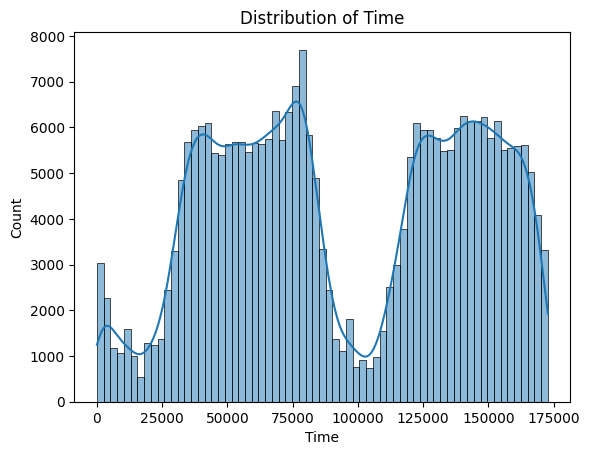

In [131]:
#Visualizing the distribution of Time which provides insights into the frequency of time
sns.histplot(creditcard_df['Time'], kde=True)
plt.title("Distribution of Time")
plt.show()

C:\Users\Vivobook pro 15\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


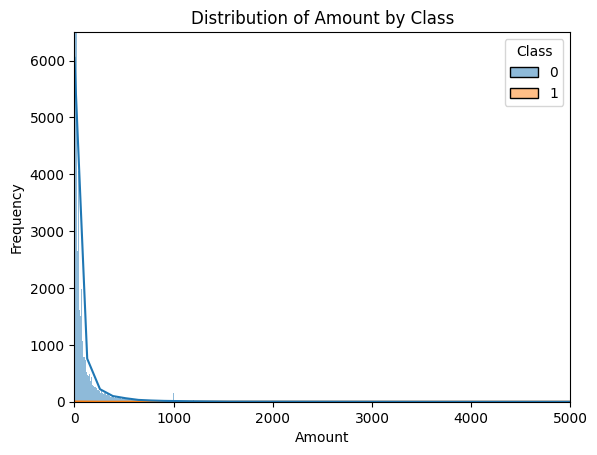

In [132]:
#Visualizing the distribution of Amount by Class
sns.histplot(creditcard_df,x='Amount',hue='Class',multiple='stack',kde=True)
# Set y-axis limit
plt.ylim(0, 6500)
# show only up to 5000 on x-axis
plt.xlim(0, 5000)   
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Amount by Class')
plt.show()

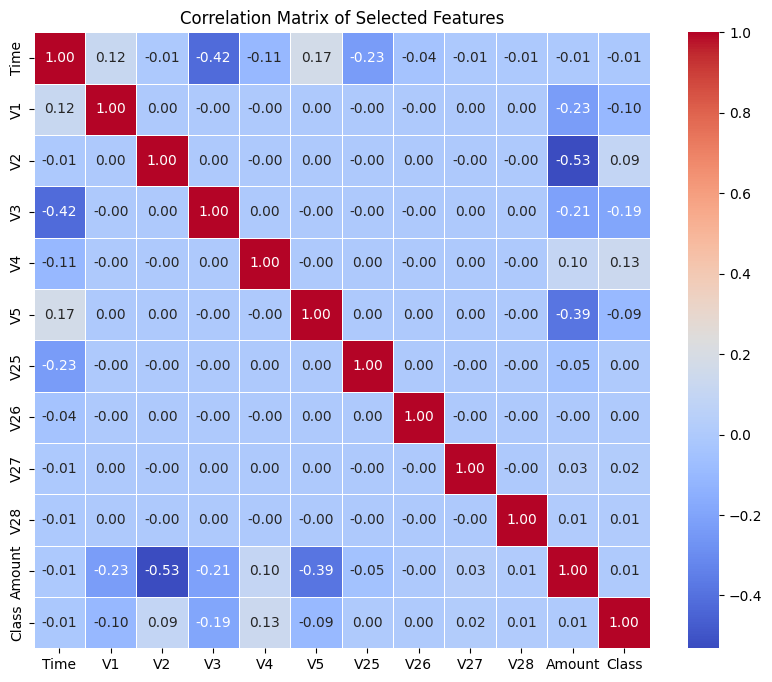

In [133]:
selected_columns = creditcard_df.columns[:6].tolist() + creditcard_df.columns[-6:].tolist()
correlation_matrix = creditcard_df[selected_columns].corr()
# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True, linewidths=0.5)
# Add title
plt.title('Correlation Matrix of Selected Features')
# Show the plot
plt.show()

In [134]:
missing_values = creditcard_df.isnull().sum().reset_index()
missing_values.columns = ['Column', 'MissingCount']
print(missing_values)

    Column  MissingCount
0     Time             0
1       V1             0
2       V2             0
3       V3             0
4       V4             0
5       V5             0
6       V6             0
7       V7             0
8       V8             0
9       V9             0
10     V10             0
11     V11             0
12     V12             0
13     V13             0
14     V14             0
15     V15             0
16     V16             0
17     V17             0
18     V18             0
19     V19             0
20     V20             0
21     V21             0
22     V22             0
23     V23             0
24     V24             0
25     V25             0
26     V26             0
27     V27             0
28     V28             0
29  Amount             0
30   Class             0


In [135]:
#Performing feature scaling on the 'Amount' column of the DataFrame creditcard_df using StandardScaler(sc).
creditcard_df['Amount'] = StandardScaler().fit_transform(creditcard_df[['Amount']])

In [136]:
#Removing the 'Time' column from the DataFrame creditcard_df.
creditcard_df=creditcard_df.drop(['Time'],axis=1)

In [137]:
#Before Removing the Duplicate Values
creditcard_df.shape

(284807, 30)

In [138]:
#Eliminating the duplicate Values in the Dataframe 
creditcard_df=creditcard_df.drop_duplicates()
creditcard_df.shape

(275663, 30)

C:\Users\Vivobook pro 15\AppData\Local\Temp\ipykernel_31040\2008462113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class',data=creditcard_df,palette=['#377EB8','#E41A1C'])


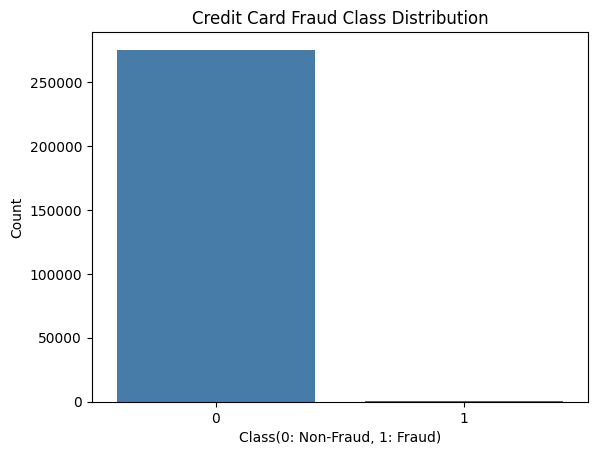

In [139]:
#Visualizing the Class distribution between Fraudulent and Normal Transactions.
sns.countplot(x='Class',data=creditcard_df,palette=['#377EB8','#E41A1C'])
plt.xlabel('Class(0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.title('Credit Card Fraud Class Distribution')
plt.show()   

## Handling Dataset Imbalance by Undersampling

In [140]:
#Storing Normal transactions in 'normal' variable and Fraud transactions in 'fraud' variable
normal=creditcard_df[creditcard_df['Class']==0]
fraud=creditcard_df[creditcard_df['Class']==1]

In [141]:
#The number of Fraud transactions
print("Number of Fraud transactions", fraud.shape)

#The number of normal transactions
print("Number of normal transactions",normal.shape)

Number of Fraud transactions (473, 30)
Number of normal transactions (275190, 30)


In [142]:
#A sample of 473 randomly selected instances is taken from the 'normal' DataFrame, and the resulting DataFrame is assigned to the variable 'normal_sample'.
normal_sample=normal.sample(n=473, random_state=42)
normal_sample.shape

(473, 30)

In [143]:
#A new DataFrame 'newcreditcard_df' is created by concatenating a sample of normal transactions with the entire fraud transactions DataFrame, and the resulting distribution of the 'Class' variable is displayed using the value counts.
newcreditcard_df=pd.concat([normal_sample,fraud],ignore_index=True)
newcreditcard_df['Class'].value_counts()

Class
0    473
1    473
Name: count, dtype: int64

C:\Users\Vivobook pro 15\AppData\Local\Temp\ipykernel_31040\1462965612.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=creditcard_df, palette=['#377EB8','#E41A1C'])
C:\Users\Vivobook pro 15\AppData\Local\Temp\ipykernel_31040\1462965612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=newcreditcard_df, palette=['#377EB8','#E41A1C'])


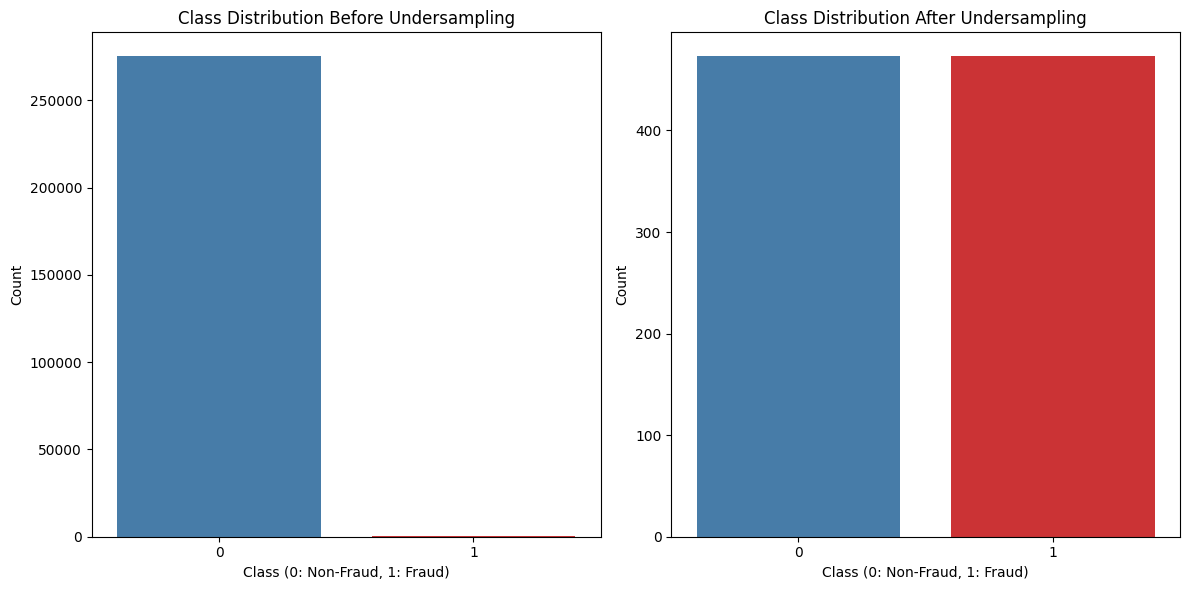

In [144]:
# Before undersampling (original dataset)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Create two side-by-side plots
sns.countplot(x='Class', data=creditcard_df, palette=['#377EB8','#E41A1C'])
plt.title('Class Distribution Before Undersampling')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
# After undersampling (newcreditcard_df)
plt.subplot(1, 2, 2)
sns.countplot(x='Class', data=newcreditcard_df, palette=['#377EB8','#E41A1C'])
plt.title('Class Distribution After Undersampling')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.tight_layout()  # Adjust subplots to fit the figure area
plt.show()

## Evaluating Performing

In [145]:
#Storing Feature Matrix in 'X' and Target Variable in 'Y'
X=newcreditcard_df.drop('Class',axis=1) #X contains independent variables
Y=newcreditcard_df['Class'] #Y contains dependent variables

In [146]:
#Splitting the dataset into Training set and Test set
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42,
                                               stratify=Y        # keeps class ratio in both splits
                                               )

##### Training the Model using Logistic Regression

In [147]:
#Training the Model using Logistic Regression 
log.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [148]:
#Predicting the Model using Logistic Regression 
Y_pred_log=log.predict(X_test)  

#Probability the Model using Logistic Regression 
Y_prob_log  = log.predict_proba(X_test)[:, 1]

In [149]:
print("\n========== Random Forest ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_log))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_log))
print(confusion_matrix(Y_test, Y_pred_log))
print(classification_report(Y_test, Y_pred_log))


========== Random Forest ==========
Accuracy : 0.9526315789473684
ROC-AUC  : 0.9722991689750693
[[95  0]
 [ 9 86]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        95
           1       1.00      0.91      0.95        95

    accuracy                           0.95       190
   macro avg       0.96      0.95      0.95       190
weighted avg       0.96      0.95      0.95       190



##### Training the Model using Decision Tree Classifier

In [150]:
#Training the Model Using Decision Tree Classifier
dt.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [151]:
#Predicting the Model Using Decision Tree Classifier
Y_pred_dt=dt.predict(X_test)
#Probability the Model using Decision Tree Classifier
Y_prob_dt  = dt.predict_proba(X_test)[:, 1]

In [152]:
print("\n========== Decision Tree Classifier ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_dt))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_dt))
print(confusion_matrix(Y_test, Y_pred_dt))
print(classification_report(Y_test, Y_pred_dt))


========== Decision Tree Classifier ==========
Accuracy : 0.8894736842105263
ROC-AUC  : 0.8894736842105262
[[80 15]
 [ 6 89]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.88        95
           1       0.86      0.94      0.89        95

    accuracy                           0.89       190
   macro avg       0.89      0.89      0.89       190
weighted avg       0.89      0.89      0.89       190



##### Training the Model using Random Forest Classifier 

In [153]:
#Training the model using Random Forest Classifier
rf.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [154]:
#Predicting the Model Using Random Forest Classifier
Y_pred_rf=rf.predict(X_test)
#Probability the Model using Random Forest Classifier
Y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [155]:
print("\n========== Random Forest Classifier ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_rf))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_rf))
print(confusion_matrix(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf))


========== Random Forest Classifier ==========
Accuracy : 0.9421052631578948
ROC-AUC  : 0.9748476454293629
[[94  1]
 [10 85]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        95
           1       0.99      0.89      0.94        95

    accuracy                           0.94       190
   macro avg       0.95      0.94      0.94       190
weighted avg       0.95      0.94      0.94       190



##### Visualizing the Evaluation of the Models

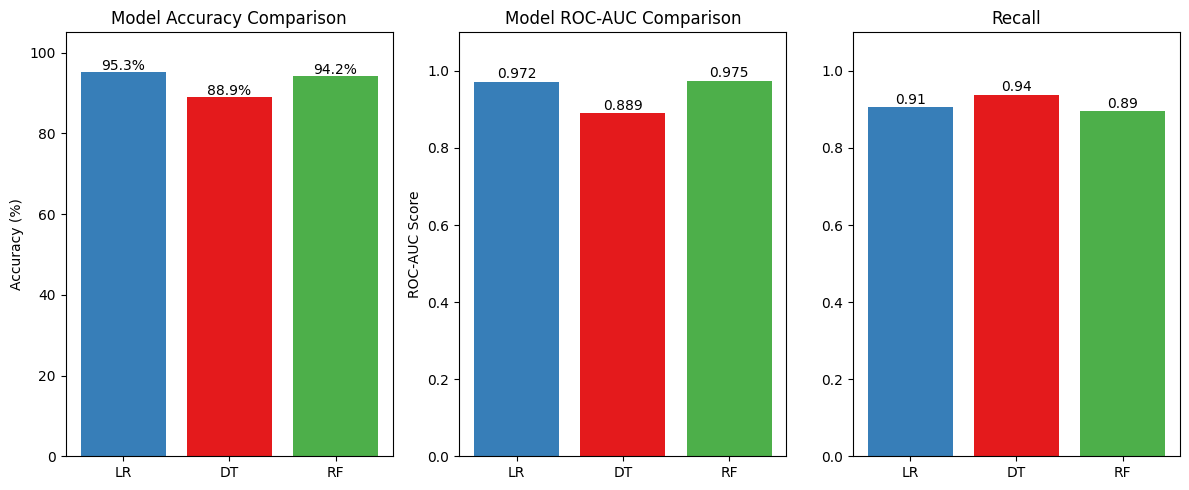

Models  Accuracy  ROC-AUC   Recall
    LR 95.263158 0.972299 0.905263
    DT 88.947368 0.889474 0.936842
    RF 94.210526 0.974848 0.894737


In [ ]:
final_accuracydata = pd.DataFrame({
    'Models'  : ['LR', 'DT', 'RF'],
    'Accuracy': [
        accuracy_score(Y_test, Y_pred_log) * 100,
        accuracy_score(Y_test, Y_pred_dt)  * 100,
        accuracy_score(Y_test, Y_pred_rf)  * 100,
    ],
    'ROC-AUC' : [
        roc_auc_score(Y_test, Y_prob_log),
        roc_auc_score(Y_test, Y_prob_dt),
        roc_auc_score(Y_test, Y_prob_rf),
    ],
    'Recall': [
    recall_score(Y_test, Y_pred_log),
    recall_score(Y_test, Y_pred_dt),
    recall_score(Y_test, Y_pred_rf),
    ],
})

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].bar(final_accuracydata['Models'], final_accuracydata['Accuracy'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
for i, v in enumerate(final_accuracydata['Accuracy']):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center')

axes[1].bar(final_accuracydata['Models'], final_accuracydata['ROC-AUC'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(final_accuracydata['ROC-AUC']):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center')
    
axes[2].bar(final_accuracydata['Models'], final_accuracydata['Recall'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[2].set_title('Model Recall Comparison')
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0, 1.1)
for i, v in enumerate(final_accuracydata['Recall']):
    axes[2].text(i, v+0.01, f'{v:.2f}', ha='center')    

plt.tight_layout()
plt.show()

print(final_accuracydata.to_string(index=False))


## Handling Dataset Imbalance — SMOTE Approach (Better than Undersampling)

In [157]:
#Storing Normal transactions in 'normal' variable and Fraud transactions in 'fraud' variable
normal = creditcard_df[creditcard_df['Class']==0]
fraud  = creditcard_df[creditcard_df['Class']==1]

In [158]:
#The number of Fraud transactions
print("Number of Fraud transactions:", fraud.shape[0])
#The number of normal transactions
print("Number of Normal transactions:", normal.shape[0])
print(f"Imbalance ratio: {normal.shape[0]//fraud.shape[0]}:1")

Number of Fraud transactions: 473
Number of Normal transactions: 275190
Imbalance ratio: 581:1


### Why SMOTE instead of Undersampling?
- Undersampling **throws away** ~283,000 legitimate transactions — huge data loss
- SMOTE **generates synthetic** minority samples — keeps all your data
- Better model learning, especially for fraud detection

C:\Users\Vivobook pro 15\AppData\Local\Temp\ipykernel_31040\1498318048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=creditcard_df, palette=['#377EB8','#E41A1C'])


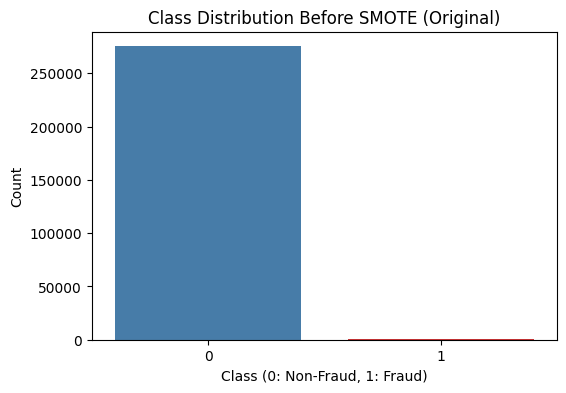

In [159]:
# Visualizing class distribution before SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=creditcard_df, palette=['#377EB8','#E41A1C'])
plt.title('Class Distribution Before SMOTE (Original)')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.show()

#### Evaluating Performance — With SMOTE Pipeline

In [160]:
#Storing Feature Matrix in 'X' and Target Variable in 'Y'
# Using full dataset — SMOTE will handle balancing inside pipeline
X = creditcard_df.drop('Class', axis=1)   # independent variables
Y = creditcard_df['Class']                 # dependent variable

In [161]:
#Splitting the dataset into Training set and Test set
# stratify=Y ensures both train/test have same class ratio
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y  
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train class distribution:", dict(Y_train.value_counts()))

Train shape: (220530, 29)
Test shape : (55133, 29)
Train class distribution: {0: 220152, 1: 378}


Before SMOTE: {0: 220152, 1: 378}
After SMOTE : {0: 220152, 1: 220152}


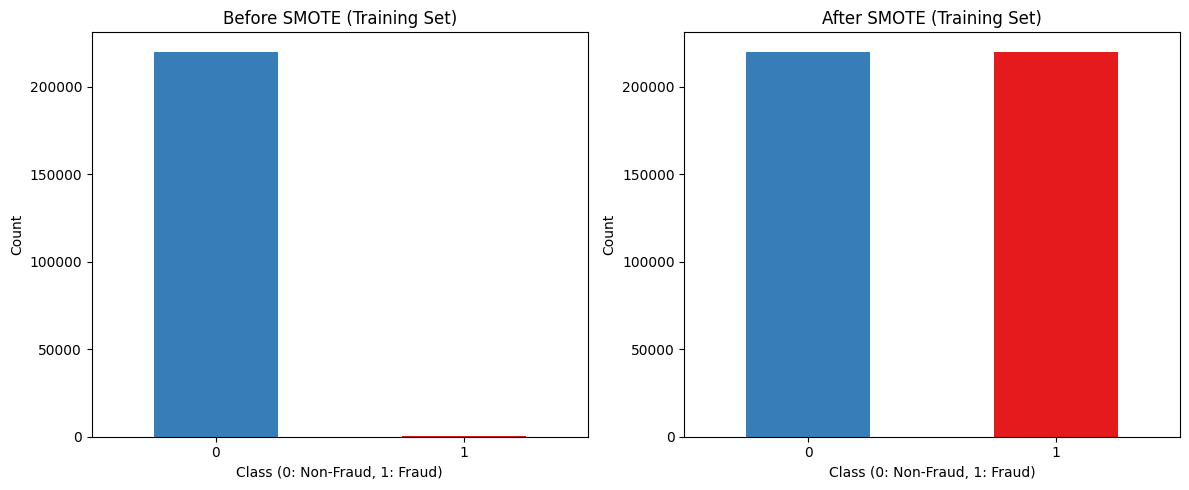

In [162]:
# Apply SMOTE only on training data — NEVER on test data
smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(X_train, Y_train)

print("Before SMOTE:", dict(Y_train.value_counts()))
print("After SMOTE :", dict(pd.Series(Y_train_sm).value_counts()))

# Visualize after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pd.Series(Y_train).value_counts().plot(kind='bar', ax=axes[0], color=['#377EB8','#E41A1C'])
axes[0].set_title('Before SMOTE (Training Set)')
axes[0].set_xlabel('Class (0: Non-Fraud, 1: Fraud)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

pd.Series(Y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=['#377EB8','#E41A1C'])
axes[1].set_title('After SMOTE (Training Set)')
axes[1].set_xlabel('Class (0: Non-Fraud, 1: Fraud)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

##### Training the Model using Logistic Regression

In [163]:
#Training the Model using Logistic Regression (on SMOTE-balanced data)
log.fit(X_train_sm, Y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [164]:
#Predicting using Logistic Regression
Y_pred_log  = log.predict(X_test)
Y_prob_log  = log.predict_proba(X_test)[:, 1]

In [165]:
print("\n========== Logistic Regression ==========")  # ← Fixed: label was wrong
print("Accuracy :", accuracy_score(Y_test, Y_pred_log))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_log))
print(confusion_matrix(Y_test, Y_pred_log))
print(classification_report(Y_test, Y_pred_log))


========== Logistic Regression ==========
Accuracy : 0.9744436181597228
ROC-AUC  : 0.9773922706034682
[[53639  1399]
 [   10    85]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     55038
           1       0.06      0.89      0.11        95

    accuracy                           0.97     55133
   macro avg       0.53      0.93      0.55     55133
weighted avg       1.00      0.97      0.99     55133



##### Training the Model using Decision Tree Classifier

In [166]:
#Training the Model Using Decision Tree Classifier (on SMOTE-balanced data)
dt.fit(X_train_sm, Y_train_sm)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [167]:
#Predicting using Decision Tree Classifier
Y_pred_dt = dt.predict(X_test)
Y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [168]:
print("\n========== Decision Tree Classifier ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_dt))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_dt))
print(confusion_matrix(Y_test, Y_pred_dt))
print(classification_report(Y_test, Y_pred_dt))


========== Decision Tree Classifier ==========
Accuracy : 0.9974062721056355
ROC-AUC  : 0.8568409194795558
[[54922   116]
 [   27    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.37      0.72      0.49        95

    accuracy                           1.00     55133
   macro avg       0.68      0.86      0.74     55133
weighted avg       1.00      1.00      1.00     55133



##### Training the Model using Random Forest Classifier 

In [169]:
#Training the model using Random Forest Classifier (on SMOTE-balanced data)
rf.fit(X_train_sm, Y_train_sm)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [170]:
#Predicting using Random Forest Classifier
Y_pred_rf = rf.predict(X_test)    # ← Fixed: was wrongly using dt.predict
Y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [171]:
print("\n========== Random Forest Classifier ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_rf))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_rf))
print(confusion_matrix(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf))


========== Random Forest Classifier ==========
Accuracy : 0.9993651714943863
ROC-AUC  : 0.9598120724246024
[[55023    15]
 [   20    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.83      0.79      0.81        95

    accuracy                           1.00     55133
   macro avg       0.92      0.89      0.91     55133
weighted avg       1.00      1.00      1.00     55133



## Training the Model using XGBoost (Best for Imbalanced Data)

In [172]:
# XGBoost with scale_pos_weight — handles imbalance natively
fraud_count  = (Y_train == 1).sum()
normal_count = (Y_train == 0).sum()
ratio = normal_count / fraud_count

xgb = XGBClassifier(
    scale_pos_weight=ratio,   # tells XGBoost about imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, Y_train)  # XGBoost handles imbalance itself — no SMOTE needed

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [173]:
#Predicting using XGBoost
Y_pred_xgb = xgb.predict(X_test)
Y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n========== XGBoost ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_xgb))
print(confusion_matrix(Y_test, Y_pred_xgb))
print(classification_report(Y_test, Y_pred_xgb))


========== XGBoost ==========
Accuracy : 0.9994014474089928
ROC-AUC  : 0.9726451198310833
[[55026    12]
 [   21    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.86      0.78      0.82        95

    accuracy                           1.00     55133
   macro avg       0.93      0.89      0.91     55133
weighted avg       1.00      1.00      1.00     55133



##### Visualizing the Evaluation of the Models

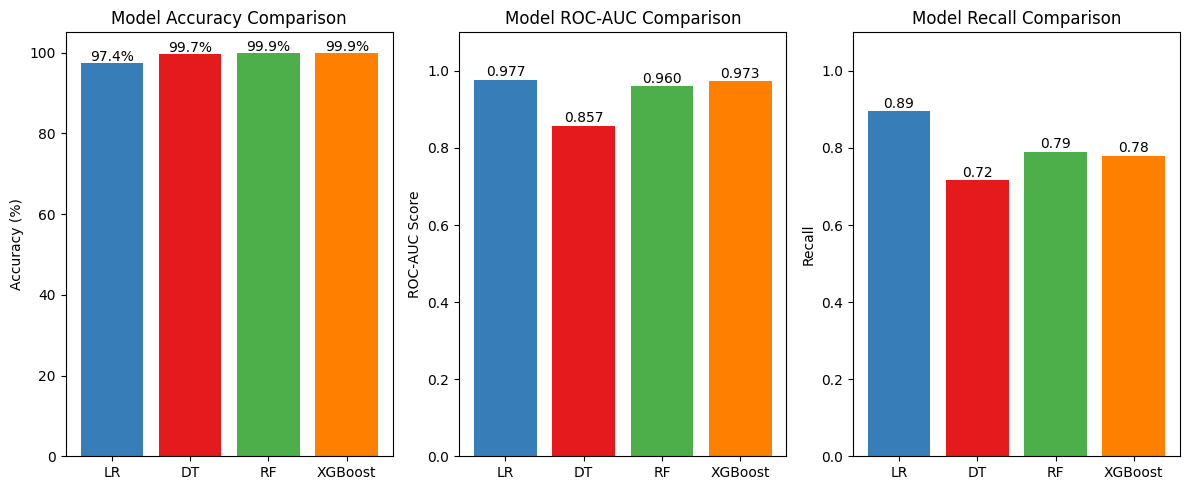

 Models  Accuracy  ROC-AUC   Recall
     LR 97.444362 0.977392 0.894737
     DT 99.740627 0.856841 0.715789
     RF 99.936517 0.959812 0.789474
XGBoost 99.940145 0.972645 0.778947


In [174]:
final_accuracydata = pd.DataFrame({
    'Models'  : ['LR', 'DT', 'RF', 'XGBoost'],
    'Accuracy': [
        accuracy_score(Y_test, Y_pred_log) * 100,
        accuracy_score(Y_test, Y_pred_dt)  * 100,
        accuracy_score(Y_test, Y_pred_rf)  * 100,
        accuracy_score(Y_test, Y_pred_xgb) * 100,
    ],
    'ROC-AUC' : [
        roc_auc_score(Y_test, Y_prob_log),
        roc_auc_score(Y_test, Y_prob_dt),
        roc_auc_score(Y_test, Y_prob_rf),
        roc_auc_score(Y_test, Y_prob_xgb),
    ],
    'Recall': [
    recall_score(Y_test, Y_pred_log),
    recall_score(Y_test, Y_pred_dt),
    recall_score(Y_test, Y_pred_rf),
    recall_score(Y_test, Y_pred_xgb),
    ],
})


# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].bar(final_accuracydata['Models'], final_accuracydata['Accuracy'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
for i, v in enumerate(final_accuracydata['Accuracy']):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center')

axes[1].bar(final_accuracydata['Models'], final_accuracydata['ROC-AUC'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(final_accuracydata['ROC-AUC']):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center')
    
axes[2].bar(final_accuracydata['Models'], final_accuracydata['Recall'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[2].set_title('Model Recall Comparison')
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0, 1.1)
for i, v in enumerate(final_accuracydata['Recall']):
    axes[2].text(i, v+0.01, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

print(final_accuracydata.to_string(index=False))

## Handling Dataset Imbalance — SMOTETomek Approach (Best overall for fraud detection)

#### Evaluating Performance — With SMOTETomek Pipeline

In [175]:
#Storing Feature Matrix in 'X' and Target Variable in 'Y'
# Using full dataset — SMOTETomek will handle balancing inside pipeline
X = creditcard_df.drop('Class', axis=1)   # independent variables
Y = creditcard_df['Class']                 # dependent variable

In [176]:
#Splitting the dataset into Training set and Test set
# stratify=Y ensures both train/test have same class ratio
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y    # ← Fixed: was stratify=y (lowercase) which caused NameError
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train class distribution:", dict(Y_train.value_counts()))

Train shape: (220530, 29)
Test shape : (55133, 29)
Train class distribution: {0: 220152, 1: 378}


Before SMOTETomek: {0: 220152, 1: 378}
After SMOTETomek : {0: 220152, 1: 220152}
Note: SMOTETomek may not perfectly balance — it also removes noisy majority samples


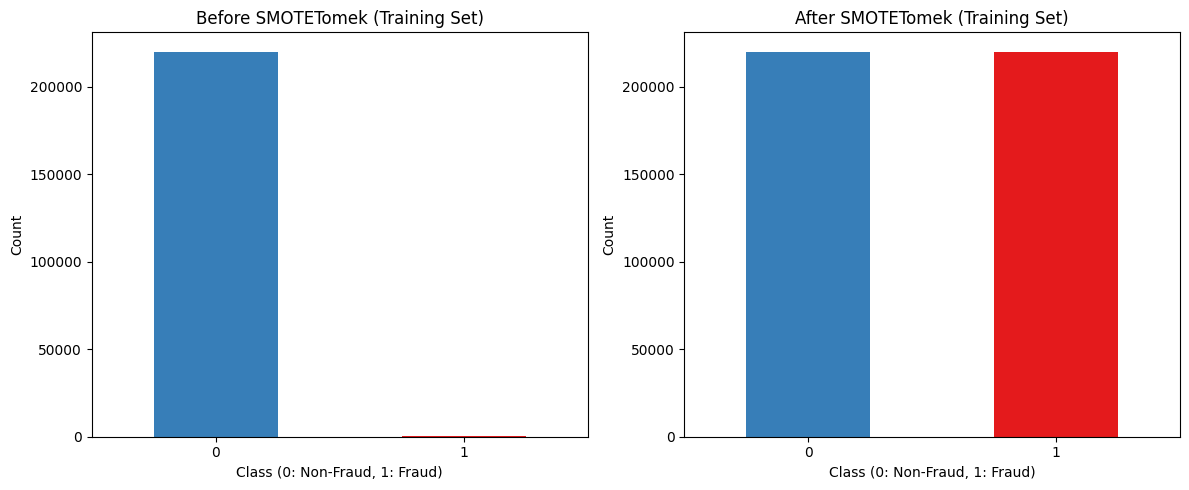

In [177]:
# Apply SMOTETomek only on training data — NEVER on test data
# SMOTETomek = SMOTE (oversample minority) + Tomek Links (remove noisy borderline samples)
smt = SMOTETomek(random_state=42)
X_train_sm, Y_train_sm = smt.fit_resample(X_train, Y_train)

print("Before SMOTETomek:", dict(Y_train.value_counts()))
print("After SMOTETomek :", dict(pd.Series(Y_train_sm).value_counts()))
print("Note: SMOTETomek may not perfectly balance — it also removes noisy majority samples")

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pd.Series(Y_train).value_counts().plot(kind='bar', ax=axes[0], color=['#377EB8','#E41A1C'])
axes[0].set_title('Before SMOTETomek (Training Set)')
axes[0].set_xlabel('Class (0: Non-Fraud, 1: Fraud)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

pd.Series(Y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=['#377EB8','#E41A1C'])
axes[1].set_title('After SMOTETomek (Training Set)')
axes[1].set_xlabel('Class (0: Non-Fraud, 1: Fraud)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

##### Training the Model using Logistic Regression

In [178]:
#Training the Model using Logistic Regression (on SMOTETomek-balanced data)
log.fit(X_train_sm, Y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [179]:
#Predicting using Logistic Regression
Y_pred_log  = log.predict(X_test)
Y_prob_log  = log.predict_proba(X_test)[:, 1]

In [180]:
print("\n========== Logistic Regression ==========")  # ← Fixed: label was wrong
print("Accuracy :", accuracy_score(Y_test, Y_pred_log))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_log))
print(confusion_matrix(Y_test, Y_pred_log))
print(classification_report(Y_test, Y_pred_log))


========== Logistic Regression ==========
Accuracy : 0.9744436181597228
ROC-AUC  : 0.9773922706034682
[[53639  1399]
 [   10    85]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     55038
           1       0.06      0.89      0.11        95

    accuracy                           0.97     55133
   macro avg       0.53      0.93      0.55     55133
weighted avg       1.00      0.97      0.99     55133



##### Training the Model using Decision Tree Classifier

In [181]:
#Training the Model Using Decision Tree Classifier (on SMOTETomek-balanced data)
dt.fit(X_train_sm, Y_train_sm)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [182]:
#Predicting using Decision Tree Classifier
Y_pred_dt = dt.predict(X_test)
Y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [183]:
print("\n========== Decision Tree Classifier ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_dt))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_dt))
print(confusion_matrix(Y_test, Y_pred_dt))
print(classification_report(Y_test, Y_pred_dt))


========== Decision Tree Classifier ==========
Accuracy : 0.9974062721056355
ROC-AUC  : 0.8568409194795558
[[54922   116]
 [   27    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.37      0.72      0.49        95

    accuracy                           1.00     55133
   macro avg       0.68      0.86      0.74     55133
weighted avg       1.00      1.00      1.00     55133



##### Training the Model using Random Forest Classifier 

In [184]:
#Training the model using Random Forest Classifier (on SMOTETomek-balanced data)
rf.fit(X_train_sm, Y_train_sm)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [185]:
#Predicting using Random Forest Classifier
Y_pred_rf = rf.predict(X_test)    # ← Fixed: was wrongly using dt.predict
Y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [186]:
print("\n========== Random Forest Classifier ==========")
print("Accuracy :", accuracy_score(Y_test, Y_pred_rf))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob_rf))
print(confusion_matrix(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf))


========== Random Forest Classifier ==========
Accuracy : 0.9993651714943863
ROC-AUC  : 0.9598120724246024
[[55023    15]
 [   20    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.83      0.79      0.81        95

    accuracy                           1.00     55133
   macro avg       0.92      0.89      0.91     55133
weighted avg       1.00      1.00      1.00     55133



##### Visualizing the Evaluation of the Models

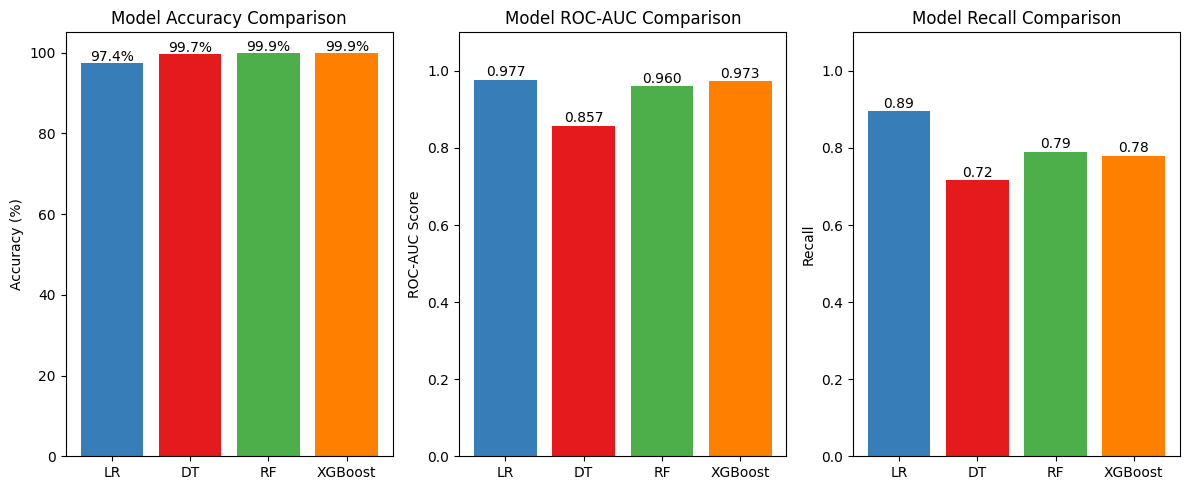

 Models  Accuracy  ROC-AUC   Recall
     LR 97.444362 0.977392 0.894737
     DT 99.740627 0.856841 0.715789
     RF 99.936517 0.959812 0.789474
XGBoost 99.940145 0.972645 0.778947


In [187]:
final_accuracydata = pd.DataFrame({
    'Models'  : ['LR', 'DT', 'RF', 'XGBoost'],
    'Accuracy': [
        accuracy_score(Y_test, Y_pred_log) * 100,
        accuracy_score(Y_test, Y_pred_dt)  * 100,
        accuracy_score(Y_test, Y_pred_rf)  * 100,
        accuracy_score(Y_test, Y_pred_xgb) * 100,
    ],
    'ROC-AUC' : [
        roc_auc_score(Y_test, Y_prob_log),
        roc_auc_score(Y_test, Y_prob_dt),
        roc_auc_score(Y_test, Y_prob_rf),
        roc_auc_score(Y_test, Y_prob_xgb),
    ],
    'Recall': [
    recall_score(Y_test, Y_pred_log),
    recall_score(Y_test, Y_pred_dt),
    recall_score(Y_test, Y_pred_rf),
    recall_score(Y_test, Y_pred_xgb),
    ],
})

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].bar(final_accuracydata['Models'], final_accuracydata['Accuracy'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
for i, v in enumerate(final_accuracydata['Accuracy']):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center')

axes[1].bar(final_accuracydata['Models'], final_accuracydata['ROC-AUC'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(final_accuracydata['ROC-AUC']):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center')
    
axes[2].bar(final_accuracydata['Models'], final_accuracydata['Recall'],
            color=['#377EB8','#E41A1C','#4DAF4A','#FF7F00'])
axes[2].set_title('Model Recall Comparison')
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0, 1.1)
for i, v in enumerate(final_accuracydata['Recall']):
    axes[2].text(i, v+0.01, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

print(final_accuracydata.to_string(index=False))

In [ ]:
# ==============================
# 15. ROC CURVE COMPARISON
# ==============================
fpr_log,  tpr_log,  _ = roc_curve(y_test, y_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_ada, _ = roc_curve(y_test, y_prob_xgb)

In [ ]:
auc_log  = roc_auc_score(y_test, y_prob_log)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf  = roc_auc_score(y_test, y_prob_rf
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_log,  tpr_log,  label=f"Logistic Regression AUC = {auc_rf:.3f}")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree               AUC = {auc_xgb:.3f}")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest   AUC = {auc_lr:.3f}")
plt.plot(fpr_xgb, tpr_xgb, label=f""XGBoost               AUC = {auc_ada:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend()
plt.tight_layout()
plt.show()